# Modeling — Predicting Loan Default

Trains and evaluates the models on the 1.35M completed loans:

1. **Logistic regression** (`class_weight='balanced'`) — interpretable
   baseline; standardized coefficients read as default drivers.
2. **Gradient boosting** (`HistGradientBoostingClassifier`) — the challenger.

Each runs twice — **all features** vs. **borrower-only** (no Lending Club
grade or interest rate) — and both are benchmarked against **LC's own
sub-grade ranking**. Evaluation uses the metrics banks use: ROC-AUC,
precision-recall, the KS statistic, and a cost-framed confusion matrix.

Canonical script version: `src/train.py`.

In [1]:
%matplotlib inline
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from features import load_features
from train import RANDOM_STATE, ks_statistic

sns.set_theme(style="whitegrid")

## Train all variants

Class imbalance (~20% defaults) is handled with **class weights** rather
than resampling — it keeps all 1.35M rows and avoids distorting the base
rate the probabilities are calibrated to.

In [2]:
scores = {}   # name -> (y_test, predicted scores)

for label, borrower_only in (("all features", False), ("borrower-only", True)):
    X, y, lender = load_features(borrower_only=borrower_only)
    X_tr, X_te, y_tr, y_te, _, lender_te = train_test_split(
        X, y, lender, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    logit = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000))
    logit.fit(X_tr, y_tr)
    scores[f"Logistic ({label})"] = (y_te, logit.predict_proba(X_te)[:, 1])

    gb = HistGradientBoostingClassifier(class_weight="balanced",
                                        random_state=RANDOM_STATE)
    gb.fit(X_tr, y_tr)
    scores[f"Grad. boosting ({label})"] = (y_te, gb.predict_proba(X_te)[:, 1])

    if borrower_only:
        feature_names_bo, logit_bo = list(X.columns), logit
    else:
        feature_names, logit_all, gb_all = list(X.columns), logit, gb

# LC's own sub-grade ordinal (A1=1..G5=35) on the same test rows
scores["LC sub-grade benchmark"] = (y_te, lender_te.to_numpy())
print("trained:", ", ".join(scores))

trained: Logistic (all features), Grad. boosting (all features), Logistic (borrower-only), Grad. boosting (borrower-only), LC sub-grade benchmark


## ROC curves

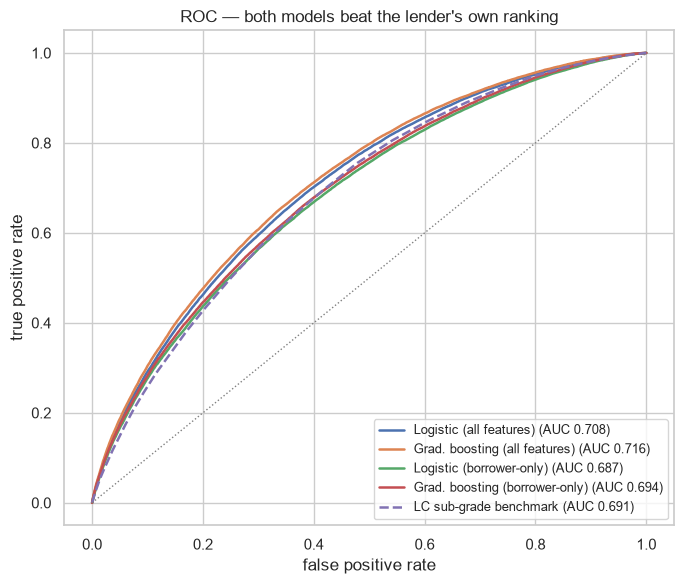

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (yt, s) in scores.items():
    fpr, tpr, _ = roc_curve(yt, s)
    style = "--" if "benchmark" in name else "-"
    ax.plot(fpr, tpr, style, lw=1.8,
            label=f"{name} (AUC {roc_auc_score(yt, s):.3f})")
ax.plot([0, 1], [0, 1], ":", c="gray", lw=1)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC — both models beat the lender's own ranking")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()

## Precision-recall

With a 20% base rate, accuracy is misleading — PR curves show what a
risk team actually faces when flagging loans.

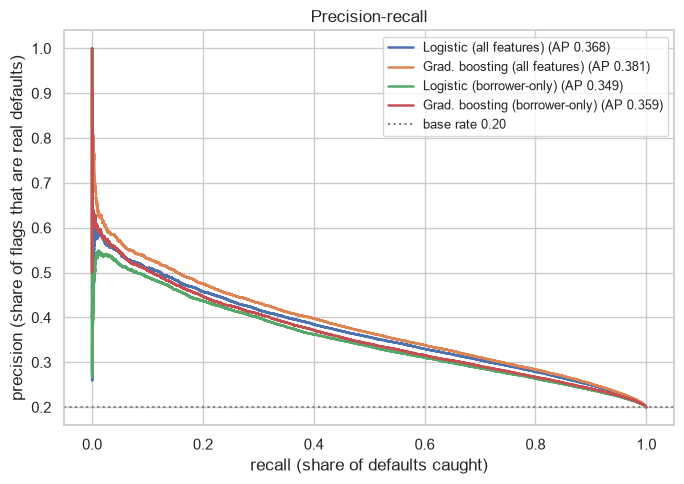

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, (yt, s) in scores.items():
    if "benchmark" in name:
        continue
    prec, rec, _ = precision_recall_curve(yt, s)
    ax.plot(rec, prec, lw=1.8,
            label=f"{name} (AP {average_precision_score(yt, s):.3f})")
yt0 = next(iter(scores.values()))[0]
ax.axhline(yt0.mean(), ls=":", c="gray", label=f"base rate {yt0.mean():.2f}")
ax.set_xlabel("recall (share of defaults caught)")
ax.set_ylabel("precision (share of flags that are real defaults)")
ax.set_title("Precision-recall")
ax.legend(fontsize=9)
plt.tight_layout()

## KS statistic — the credit-scoring standard

KS is the maximum separation between the cumulative score distributions of
defaulters and non-defaulters; credit teams read it as how well a score
splits goods from bads.

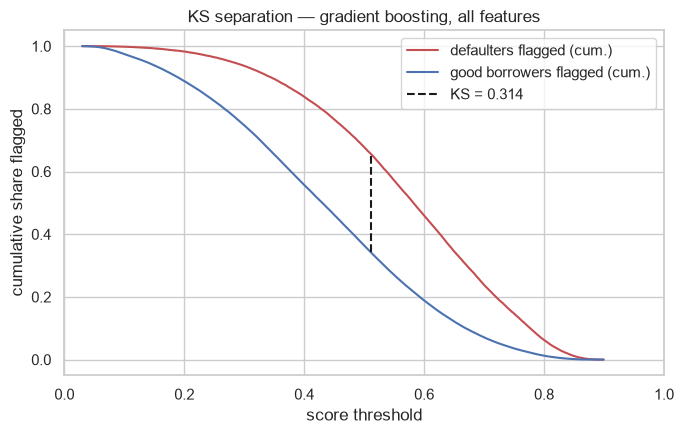

In [5]:
yt, s = scores["Grad. boosting (all features)"]
fpr, tpr, thr = roc_curve(yt, s)
ks_i = np.argmax(tpr - fpr)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr, tpr, label="defaulters flagged (cum.)", c="#c44e52")
ax.plot(thr, fpr, label="good borrowers flagged (cum.)", c="#4c72b0")
ax.vlines(thr[ks_i], fpr[ks_i], tpr[ks_i], color="k", ls="--",
          label=f"KS = {tpr[ks_i] - fpr[ks_i]:.3f}")
ax.set_xlim(0, 1)
ax.set_xlabel("score threshold")
ax.set_ylabel("cumulative share flagged")
ax.set_title("KS separation — gradient boosting, all features")
ax.legend()
plt.tight_layout()

## Confusion matrix at the 0.5 threshold — the business framing

A missed default costs principal; a falsely flagged good borrower costs
interest income. The 0.5 threshold on the class-weighted model is a
reasonable operating point; a cost-based threshold sweep is the natural
extension.

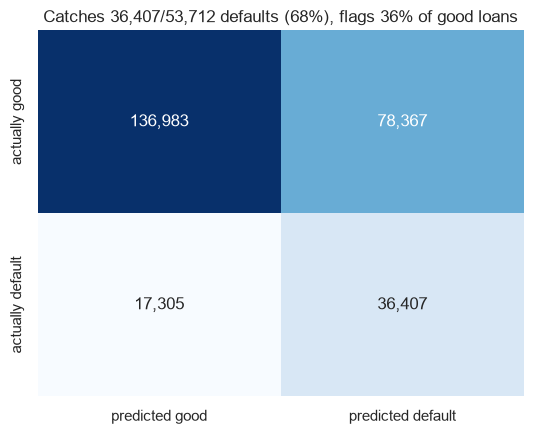

In [6]:
yt, s = scores["Grad. boosting (all features)"]
tn, fp, fn, tp = confusion_matrix(yt, s >= 0.5).ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt=",", cbar=False,
            cmap="Blues", ax=ax,
            xticklabels=["predicted good", "predicted default"],
            yticklabels=["actually good", "actually default"])
ax.set_title(f"Catches {tp:,}/{tp + fn:,} defaults ({tp / (tp + fn):.0%}), "
             f"flags {fp / (fp + tn):.0%} of good loans")
plt.tight_layout()

## What drives default? Logistic coefficients

Standardized coefficients (features were scaled), so magnitudes are
comparable; positive = raises default risk.

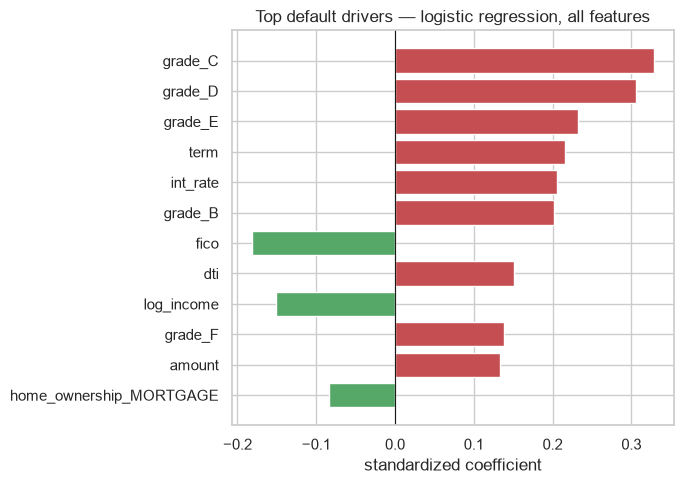

In [7]:
coefs = (pd.Series(logit_all[-1].coef_[0], index=feature_names)
           .sort_values(key=abs).tail(12))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(coefs.index, coefs.values,
        color=["#c44e52" if v > 0 else "#55a868" for v in coefs.values])
ax.axvline(0, c="k", lw=0.8)
ax.set_xlabel("standardized coefficient")
ax.set_title("Top default drivers — logistic regression, all features")
plt.tight_layout()

## Summary

In [8]:
summary = pd.DataFrame(
    [{"model": name,
      "ROC-AUC": roc_auc_score(yt, s),
      "PR-AUC": average_precision_score(yt, s),
      "KS": ks_statistic(yt, s)}
     for name, (yt, s) in scores.items()]).round(3)
summary

,model,ROC-AUC,PR-AUC,KS
0,Logistic (all features),0.708,0.368,0.303
1,Grad. boosting (all features),0.716,0.381,0.314
2,Logistic (borrower-only),0.687,0.349,0.270
3,Grad. boosting (borrower-only),0.694,0.359,0.279
4,LC sub-grade benchmark,0.691,0.335,0.278


## Takeaways

- **Best model:** gradient boosting with all features — **0.716 ROC-AUC,
  KS 0.314**, catching ~68% of defaults at the 0.5 threshold.
- **Interpretable story:** grade dummies, term, interest rate, FICO and DTI
  dominate the logistic coefficients — the same drivers the SQL analysis
  surfaced.
- **Beating the lender:** using *only borrower attributes* (no grade, no
  rate), gradient boosting reaches **0.694 AUC vs. 0.691** for Lending
  Club's own sub-grade ranking — a from-scratch model matches the lender's
  pricing signal.
- AUCs around 0.71 are in line with published results on this dataset:
  consumer-credit default is genuinely noisy, which is why banks lean on
  interpretability and calibration as much as raw discrimination.